In [1]:
import numpy as np, curvedsky as cs, plottools as pl, cmb as CMB, cosmology, healpy as hp, local, tools_cmb
from matplotlib.pyplot import *
import warnings
warnings.filterwarnings("ignore")
ac2rad  = np.pi/10800.
deg2rad = np.pi/180.
Tcmb  = CMB.Tcmb    # CMB temperature

In [2]:
lmax = 2048
l = np.linspace(0,lmax,lmax+1)

In [3]:
aobj = local.init_analysis(freq='143',ascale=0.5)

In [4]:
wind = local.set_mask(aobj.famask)[0]

In [5]:
mask = hp.fitsfunc.read_map('../data/plk_biref/mask/COM_Mask_Lensing_2048_R3.00_a1.0deg.fits')

In [49]:
W = mask * wind
#W = wind

In [82]:
tmap = W * tools_cmb.reduc_map(aobj.dtype,aobj.fimap['s'][0],field=0)

In [83]:
#print(np.mean(tmap0))

5.768628595859753e-05


In [84]:
#tmap = W*(tmap0-np.mean(tmap0))

In [85]:
#print(np.mean(tmap))

3.9492157376640164e-07


In [51]:
Tmap = W*tools_cmb.reduc_map(aobj.dtype,aobj.fimap['s'][1],field=0)

In [52]:
Nmap = W*tools_cmb.reduc_map(aobj.dtype,aobj.fimap['n'][1],field=0)

In [56]:
ibl = np.exp(l*(l+1.)*(5.*ac2rad)**2/16./np.log(2.))

In [88]:
talm = cs.utils.hp_map2alm(2048,lmax,lmax,tmap) * ibl[:,None]

In [70]:
Talm = cs.utils.hp_map2alm(2048,lmax,lmax,Tmap) * ibl[:,None]
Nalm = cs.utils.hp_map2alm(2048,lmax,lmax,Nmap) * ibl[:,None]

In [89]:
cl = cs.utils.alm2cl(lmax,talm)
Cl = cs.utils.alm2cl(lmax,Talm+Nalm)

In [91]:
fgfiles = aobj.fgmap
clfg = {}
Tlmfg = 0.
lmax = 2048
for key in fgfiles.keys():
#for key in ['thermaldust','strongps','strongradiops','freefree','stronguchii','synchrotron']:
    print(key)
    Tfg = W * hp.ud_grade(hp.fitsfunc.read_map(fgfiles[key],field=0),2048) / 2.726
    #Tfg = W * (Tfg0-np.mean(Tfg))
    #Qfg = hp.fitsfunc.read_map(fgfiles[key],field=1)
    #Ufg = hp.fitsfunc.read_map(fgfiles[key],field=2)
    nside = hp.get_nside(Tfg)
    Tlm = cs.utils.hp_map2alm(nside,lmax,lmax,Tfg)
    Tlmfg += Tlm
    clfg[key] = cs.utils.alm2cl(lmax,Tlm)

clusterirps
freefree
stronguchii
kineticsz
synchrotron
co
faintirps
faintps
faintradiops
spindust
strongps
strongradiops
sz
thermaldust
thermalsz


In [92]:
Cltot = cs.utils.alm2cl(lmax,Tlmfg+Talm+Nalm)

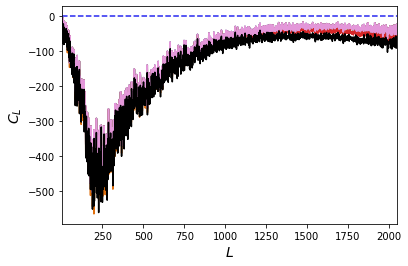

In [93]:
pl.plot_1dstyle(xmin=2,xmax=2048)
#plot(cl)
s = l**2/2/np.pi*2.72e6**2
plot(l,s*(cl-Cl))
for key in ['thermaldust','strongps','strongradiops','freefree','stronguchii','synchrotron']:
    plot(l,s*(cl-clfg[key]-Cl))
plot(l,s*(cl-Cltot),color='k')
axhline(0,ls='--')

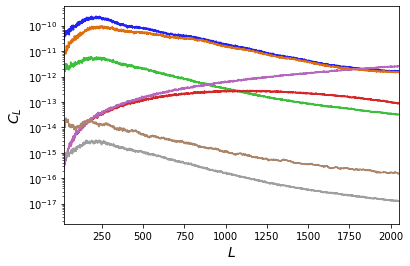

In [65]:
pl.plot_1dstyle(ylog=True)
s = l*(l+1.)/2./np.pi
plot(l,s*cl)
plot(l,s*Cl)
for key in ['thermaldust','strongps','strongradiops','freefree','stronguchii','synchrotron']:
    plot(l,s*(clfg[key]))
#axhline(1,color='k')
#plot(l,(Sl+Nl))

In [17]:
qmap = tools_cmb.reduc_map(aobj.dtype,aobj.fimap['s'][0],field=1)
umap = tools_cmb.reduc_map(aobj.dtype,aobj.fimap['s'][0],field=2)

In [18]:
sQmap = tools_cmb.reduc_map(aobj.dtype,aobj.fimap['s'][1],field=1)
sUmap = tools_cmb.reduc_map(aobj.dtype,aobj.fimap['s'][1],field=2)
nQmap = tools_cmb.reduc_map(aobj.dtype,aobj.fimap['n'][1],field=1)
nUmap = tools_cmb.reduc_map(aobj.dtype,aobj.fimap['n'][1],field=2)

In [19]:
ealm, balm = cs.utils.hp_map2alm_spin(2048,lmax,lmax,2,qmap,umap)

In [20]:
Ealm, Balm = cs.utils.hp_map2alm_spin(2048,lmax,lmax,2,(sQmap+nQmap),(sUmap+nUmap))

In [21]:
ee = cs.utils.alm2cl(lmax,ealm)
bb = cs.utils.alm2cl(lmax,balm)
EE = cs.utils.alm2cl(lmax,Ealm)
BB = cs.utils.alm2cl(lmax,Balm)

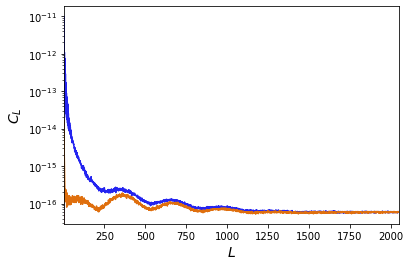

In [22]:
pl.plot_1dstyle(xmin=2,xmax=2048,ylog=True)
plot(ee)
plot(EE)

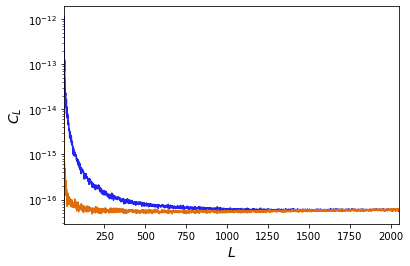

In [23]:
pl.plot_1dstyle(xmin=2,xmax=2048,ylog=True)
plot(bb)
plot(BB)